### Business Problem: Customer Churn

In [2]:
from dotenv import load_dotenv
import os
os.chdir(r"INSERT//WORKING//DIRECTORY")
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings
warnings.filterwarnings("ignore")
from scipy.stats import pearsonr
os.getcwd()
import psycopg2
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
import numpy as np
import pandas as pd
from datetime import date
from psycopg2.extras import execute_values
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from interpret.glassbox import ExplainableBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
import shap
import matplotlib.pyplot as plt
from xgboost import plot_importance
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, GradientBoostingClassifier, StackingClassifier
from lime.lime_tabular import LimeTabularExplainer
from sklearn.preprocessing import StandardScaler
import time
import sys
from imblearn.over_sampling import SMOTE

In [3]:
load_dotenv()

True

In [4]:
DB_HOST = os.getenv("DB_HOST")
DB_NAME = os.getenv("DB_NAME")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")

In [5]:
DB_NAME

'postgres'

# Data Collection

In [7]:
conn = psycopg2.connect(
    host=os.getenv("DB_HOST"),
    database=os.getenv("DB_NAME"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    port=os.getenv("DB_PORT")
)

cursor = conn.cursor()
run_date = date.today()

In [8]:
query = """
WITH max_date AS (
    SELECT MAX(created_at) AS max_order_date
    FROM ecom.orders
),

cutoff AS (
    SELECT 
        (DATE_TRUNC('month', max_order_date) - INTERVAL '1 month') - INTERVAL '1 day' AS cutoff_date,
        max_order_date
    FROM max_date
),

-- Only customers with at least 1 paid order before cutoff
eligible_customers AS (
    SELECT DISTINCT o.customer_id
    FROM ecom.orders o
    CROSS JOIN cutoff c
    WHERE o.payment_status = 'paid'
      AND o.created_at <= c.cutoff_date
),

base_customers AS (
    SELECT
        c.customer_id,
        c.acquisition_channel,
        c.country,
        c.created_at AS customer_created_at,
        c.is_email_verified,
        c.marketing_opt_in
    FROM ecom.customers c
    INNER JOIN eligible_customers ec
        ON c.customer_id = ec.customer_id
    CROSS JOIN cutoff cu
    WHERE c.created_at <= cu.cutoff_date
),

orders_agg AS (
    SELECT
        o.customer_id,
        COUNT(*) FILTER (WHERE o.payment_status = 'paid') AS total_orders,
        SUM(o.total) FILTER (WHERE o.payment_status = 'paid') AS total_revenue,
        AVG(o.total) FILTER (WHERE o.payment_status = 'paid') AS avg_order_value,
        MAX(o.created_at) FILTER (WHERE o.payment_status = 'paid') AS last_order_date,
        MIN(o.created_at) FILTER (WHERE o.payment_status = 'paid') AS first_order_date,
        COUNT(*) FILTER (WHERE o.applied_coupon_id IS NOT NULL) AS coupon_usage_count
    FROM ecom.orders o
    CROSS JOIN cutoff c
    WHERE o.created_at <= c.cutoff_date
    GROUP BY o.customer_id
),

order_items_agg AS (
    SELECT
        o.customer_id,
        COUNT(DISTINCT oi.variant_id) AS product_variety,
        SUM(oi.qty) AS total_items_purchased
    FROM ecom.orders o
    JOIN ecom.order_items oi ON o.order_id = oi.order_id
    CROSS JOIN cutoff c
    WHERE o.created_at <= c.cutoff_date
      AND o.payment_status = 'paid'
    GROUP BY o.customer_id
),

product_diversity AS (
    SELECT
        o.customer_id,
        COUNT(DISTINCT p.category_id) AS category_diversity,
        COUNT(DISTINCT p.brand_id) AS brand_diversity
    FROM ecom.orders o
    JOIN ecom.order_items oi ON o.order_id = oi.order_id
    JOIN ecom.product_variants pv ON oi.variant_id = pv.variant_id
    JOIN ecom.products p ON pv.product_id = p.product_id
    CROSS JOIN cutoff c
    WHERE o.created_at <= c.cutoff_date
      AND o.payment_status = 'paid'
    GROUP BY o.customer_id
),

sessions_agg AS (
    SELECT
        s.customer_id,
        COUNT(*) AS total_sessions,
        MAX(s.started_at) AS last_session_date,
        AVG(EXTRACT(EPOCH FROM (s.ended_at - s.started_at))) AS avg_session_duration
    FROM ecom.sessions s
    CROSS JOIN cutoff c
    WHERE s.started_at <= c.cutoff_date
    GROUP BY s.customer_id
),

event_agg AS (
    SELECT
        e.customer_id,
        COUNT(*) FILTER (WHERE e.event_type = 'product_view') AS product_views,
        COUNT(*) FILTER (WHERE e.event_type = 'add_to_cart') AS add_to_cart,
        COUNT(*) FILTER (WHERE e.event_type = 'begin_checkout') AS checkouts,
        COUNT(DISTINCT e.product_id) AS unique_products_viewed,
        COUNT(*) FILTER (WHERE e.event_type = 'search') AS search_count
    FROM ecom.session_events e
    CROSS JOIN cutoff c
    WHERE e.event_time <= c.cutoff_date
    GROUP BY e.customer_id
),

payment_failures AS (
    SELECT
        o.customer_id,
        COUNT(*) FILTER (WHERE o.payment_status = 'failed') AS failed_payments,
        COUNT(*) AS total_payment_attempts
    FROM ecom.orders o
    CROSS JOIN cutoff c
    WHERE o.created_at <= c.cutoff_date
    GROUP BY o.customer_id
),

refunds_agg AS (
    SELECT
        o.customer_id,
        SUM(r.amount) AS total_refunds,
        COUNT(DISTINCT r.order_id) AS returned_orders
    FROM ecom.refunds r
    JOIN ecom.orders o ON r.order_id = o.order_id
    CROSS JOIN cutoff c
    WHERE o.created_at <= c.cutoff_date
    GROUP BY o.customer_id
),

device_usage AS (
    SELECT
        s.customer_id,
        COUNT(DISTINCT d.device_type) AS device_types_used
    FROM ecom.sessions s
    JOIN ecom.devices d ON s.device_id = d.device_id
    CROSS JOIN cutoff c
    WHERE s.started_at <= c.cutoff_date
    GROUP BY s.customer_id
),

future_orders AS (
    SELECT
        o.customer_id,
        COUNT(*) AS orders_next_30d
    FROM ecom.orders o
    CROSS JOIN cutoff c
    WHERE o.payment_status = 'paid'
      AND o.created_at > c.cutoff_date
      AND o.created_at <= c.cutoff_date + INTERVAL '45 days'
    GROUP BY o.customer_id
)

SELECT
    bc.customer_id,
    bc.acquisition_channel,
    bc.country,
    bc.is_email_verified,
    bc.marketing_opt_in,

    DATE_PART('day', c.cutoff_date - bc.customer_created_at) AS customer_age_days,

    oa.total_orders,
    oa.total_revenue,
    oa.avg_order_value,
    oa.coupon_usage_count,

    DATE_PART('day', c.cutoff_date - oa.last_order_date) AS recency_days,

    CASE 
        WHEN oa.total_orders > 1 
        THEN DATE_PART('day', oa.last_order_date - oa.first_order_date) / (oa.total_orders - 1)
    END AS avg_order_gap,

    sa.total_sessions,
    sa.avg_session_duration,

    CASE 
        WHEN sa.last_session_date IS NOT NULL 
        THEN DATE_PART('day', c.cutoff_date - sa.last_session_date)
    END AS recency_session,

    ea.product_views,
    ea.add_to_cart,
    ea.checkouts,
    ea.unique_products_viewed,
    ea.search_count,

    ea.add_to_cart::float / NULLIF(ea.product_views, 0) AS view_to_cart_rate,
    ea.checkouts::float / NULLIF(ea.add_to_cart, 0) AS cart_to_checkout_rate,

    oi.product_variety,
    oi.total_items_purchased,

    pd.category_diversity,
    pd.brand_diversity,

    pf.failed_payments,
    pf.failed_payments::float / NULLIF(pf.total_payment_attempts, 0) AS payment_failure_rate,

    ra.total_refunds,
    ra.returned_orders,
    ra.returned_orders::float / NULLIF(oa.total_orders, 0) AS return_order_rate,
    ra.total_refunds::float / NULLIF(oa.total_revenue, 0) AS refund_rate,

    CASE
        WHEN COALESCE(ra.returned_orders, 0) > 0 THEN 1
        ELSE 0
    END AS has_return_history,

    COALESCE(du.device_types_used, 0) AS device_types_used,

    CASE
        WHEN c.cutoff_date + INTERVAL '45 days' > c.max_order_date THEN NULL
        WHEN COALESCE(fo.orders_next_30d, 0) = 0 THEN 1
        ELSE 0
    END AS churn_label

FROM base_customers bc
LEFT JOIN orders_agg oa ON bc.customer_id = oa.customer_id
LEFT JOIN order_items_agg oi ON bc.customer_id = oi.customer_id
LEFT JOIN product_diversity pd ON bc.customer_id = pd.customer_id
LEFT JOIN sessions_agg sa ON bc.customer_id = sa.customer_id
LEFT JOIN event_agg ea ON bc.customer_id = ea.customer_id
LEFT JOIN payment_failures pf ON bc.customer_id = pf.customer_id
LEFT JOIN refunds_agg ra ON bc.customer_id = ra.customer_id
LEFT JOIN device_usage du ON bc.customer_id = du.customer_id
LEFT JOIN future_orders fo ON bc.customer_id = fo.customer_id
CROSS JOIN cutoff c;
"""

In [9]:
conn.rollback()

In [10]:
df = pd.read_sql(query, conn)
df

,customer_id,acquisition_channel,country,is_email_verified,marketing_opt_in,customer_age_days,total_orders,total_revenue,avg_order_value,coupon_usage_count,...,brand_diversity,failed_payments,payment_failure_rate,total_refunds,returned_orders,return_order_rate,refund_rate,has_return_history,device_types_used,churn_label
0,6,paid,India,True,True,12.0,2,10944.97,5472.4850,1,...,3,1,0.333333,NaN,NaN,NaN,NaN,0,1,0
1,10,referral,India,True,True,6.0,2,7251.08,3625.5400,0,...,3,1,0.333333,NaN,NaN,NaN,NaN,0,1,0
2,12,organic,United States,True,False,14.0,1,905.56,905.5600,0,...,1,0,0.000000,NaN,NaN,NaN,NaN,0,2,0
3,14,organic,India,False,False,19.0,4,25357.79,6339.4475,1,...,7,0,0.000000,NaN,NaN,NaN,NaN,0,1,0
4,18,paid,India,False,False,18.0,1,4071.43,4071.4300,1,...,2,0,0.000000,NaN,NaN,NaN,NaN,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2712,9991,organic,India,True,True,7.0,1,16693.24,16693.2400,1,...,3,0,0.000000,NaN,NaN,NaN,NaN,0,2,0
2713,9994,organic,United States,True,False,30.0,2,6075.53,3037.7650,1,...,2,0,0.000000,NaN,NaN,NaN,NaN,0,2,0
2714,9995,organic,India,True,True,30.0,1,14986.95,14986.9500,1,...,3,0,0.000000,NaN,NaN,NaN,NaN,0,1,0
2715,9996,referral,India,True,False,31.0,3,35415.93,11805.3100,1,...,9,0,0.000000,NaN,NaN,NaN,NaN,0,1,1


In [11]:
df.isna().sum()

customer_id                  0
acquisition_channel          0
country                      0
is_email_verified            0
marketing_opt_in             0
customer_age_days            0
total_orders                 0
total_revenue                0
avg_order_value              0
coupon_usage_count           0
recency_days                 0
avg_order_gap             1230
total_sessions             278
avg_session_duration       278
recency_session            278
product_views              279
add_to_cart                279
checkouts                  279
unique_products_viewed     279
search_count               279
view_to_cart_rate          692
cart_to_checkout_rate     1267
product_variety              0
total_items_purchased        0
category_diversity           0
brand_diversity              0
failed_payments              0
payment_failure_rate         0
total_refunds             2679
returned_orders           2679
return_order_rate         2679
refund_rate               2679
has_retu

In [12]:
df_copy = df.copy()


# -----------------------
# 1. COUNT FEATURES
# -----------------------
count_cols = [
    "total_orders",
    "product_views",
    "add_to_cart",
    "checkouts",
    "total_sessions",
    "failed_payments",
    "returned_orders",
    "product_variety",
    "total_items_purchased",
    "category_diversity",
    "brand_diversity",
    "unique_products_viewed",
    "search_count",
    "coupon_usage_count",
    "device_types_used"
]

for col in count_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)


# -----------------------
# 2. MONETARY FEATURES
# -----------------------
monetary_cols = [
    "total_revenue",
    "avg_order_value",
    "total_refunds"
]

for col in monetary_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)


# -----------------------
# 3. RATIO FEATURES (CRITICAL)
# -----------------------
ratio_cols = [
    "view_to_cart_rate",
    "cart_to_checkout_rate",
    "payment_failure_rate",
    "return_order_rate",
    "refund_rate"
]

for col in ratio_cols:
    if col in df.columns:
        df[col + "_missing"] = df[col].isna().astype(int)
        df[col] = df[col].fillna(0)


# -----------------------
# 4. RECENCY FEATURES
# -----------------------
recency_cols = [
    "recency_days",
    "recency_session"
]

for col in recency_cols:
    if col in df.columns:
        df[col + "_missing"] = df[col].isna().astype(int)
        df[col] = df[col].fillna(df[col].max())


# -----------------------
# 5. TIME / CUSTOMER MATURITY
# -----------------------
time_cols = [
    "customer_age_days",
    "avg_order_gap",
    "avg_session_duration"
]

for col in time_cols:
    if col in df.columns:
        df[col + "_missing"] = df[col].isna().astype(int)
        df[col] = df[col].fillna(df[col].median())


# -----------------------
# 6. BOOLEAN / FLAGS
# -----------------------
flag_cols = [
    "has_return_history",
    "is_email_verified",
    "marketing_opt_in"
]

for col in flag_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# -----------------------
# 7. FINAL SAFETY CHECK
# -----------------------
missing_summary = df.isna().sum()
print("Remaining missing values:\n", missing_summary[missing_summary > 0])

Remaining missing values:
 Series([], dtype: int64)


In [13]:
df.isnull().sum()

customer_id                      0
acquisition_channel              0
country                          0
is_email_verified                0
marketing_opt_in                 0
customer_age_days                0
total_orders                     0
total_revenue                    0
avg_order_value                  0
coupon_usage_count               0
recency_days                     0
avg_order_gap                    0
total_sessions                   0
avg_session_duration             0
recency_session                  0
product_views                    0
add_to_cart                      0
checkouts                        0
unique_products_viewed           0
search_count                     0
view_to_cart_rate                0
cart_to_checkout_rate            0
product_variety                  0
total_items_purchased            0
category_diversity               0
brand_diversity                  0
failed_payments                  0
payment_failure_rate             0
total_refunds       

In [14]:
missing_flag_cols = [col for col in df.columns if col.endswith("_missing")]

for col in missing_flag_cols:
    if df[col].sum() == 0:  # no missing values ever existed
        df.drop(columns=col, inplace=True)

In [15]:
df.isnull().sum()

customer_id                      0
acquisition_channel              0
country                          0
is_email_verified                0
marketing_opt_in                 0
customer_age_days                0
total_orders                     0
total_revenue                    0
avg_order_value                  0
coupon_usage_count               0
recency_days                     0
avg_order_gap                    0
total_sessions                   0
avg_session_duration             0
recency_session                  0
product_views                    0
add_to_cart                      0
checkouts                        0
unique_products_viewed           0
search_count                     0
view_to_cart_rate                0
cart_to_checkout_rate            0
product_variety                  0
total_items_purchased            0
category_diversity               0
brand_diversity                  0
failed_payments                  0
payment_failure_rate             0
total_refunds       

In [16]:

# -----------------------
# 1. Correlation matrix
# -----------------------
corr_matrix = df.corr(numeric_only=True).abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

threshold = 0.85

to_drop = []

# -----------------------
# 2. Protected columns
# -----------------------
protected = [
    "customer_id",
    "churn_label",
    "total_orders",
    "total_revenue",
    "recency_days"
]

# -----------------------
# 3. Selection logic
# -----------------------
for col in upper.columns:
    for row in upper.index:
        if upper.loc[row, col] > threshold:

            if col in protected or row in protected:
                continue

            # Prefer log over raw
            if col.endswith("_log") and not row.endswith("_log"):
                to_drop.append(row)
            elif row.endswith("_log") and not col.endswith("_log"):
                to_drop.append(col)

            # Prefer ratios over raw counts
            elif "rate" in col and "rate" not in row:
                to_drop.append(row)
            elif "rate" in row and "rate" not in col:
                to_drop.append(col)

            else:
                # fallback: drop second
                to_drop.append(col)

# remove duplicates
to_drop = list(set(to_drop))

print("Dropping columns:", to_drop)

df = df.drop(columns=to_drop, errors="ignore")

Dropping columns: ['total_items_purchased', 'has_return_history', 'return_order_rate_missing', 'returned_orders', 'brand_diversity', 'refund_rate_missing', 'failed_payments', 'category_diversity', 'refund_rate', 'avg_session_duration_missing']


In [17]:
df

,customer_id,acquisition_channel,country,is_email_verified,marketing_opt_in,customer_age_days,total_orders,total_revenue,avg_order_value,coupon_usage_count,...,product_variety,payment_failure_rate,total_refunds,return_order_rate,device_types_used,churn_label,view_to_cart_rate_missing,cart_to_checkout_rate_missing,recency_session_missing,avg_order_gap_missing
0,6,paid,India,True,True,12.0,2,10944.97,5472.4850,1,...,3,0.333333,0.0,0.0,1,0,0,0,0,0
1,10,referral,India,True,True,6.0,2,7251.08,3625.5400,0,...,3,0.333333,0.0,0.0,1,0,0,1,0,0
2,12,organic,United States,True,False,14.0,1,905.56,905.5600,0,...,1,0.000000,0.0,0.0,2,0,0,1,0,1
3,14,organic,India,False,False,19.0,4,25357.79,6339.4475,1,...,7,0.000000,0.0,0.0,1,0,0,0,0,0
4,18,paid,India,False,False,18.0,1,4071.43,4071.4300,1,...,2,0.000000,0.0,0.0,2,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2712,9991,organic,India,True,True,7.0,1,16693.24,16693.2400,1,...,3,0.000000,0.0,0.0,2,0,0,0,0,1
2713,9994,organic,United States,True,False,30.0,2,6075.53,3037.7650,1,...,2,0.000000,0.0,0.0,2,0,0,0,0,0
2714,9995,organic,India,True,True,30.0,1,14986.95,14986.9500,1,...,3,0.000000,0.0,0.0,1,0,0,1,0,1
2715,9996,referral,India,True,False,31.0,3,35415.93,11805.3100,1,...,9,0.000000,0.0,0.0,1,1,0,1,0,0


# EDA

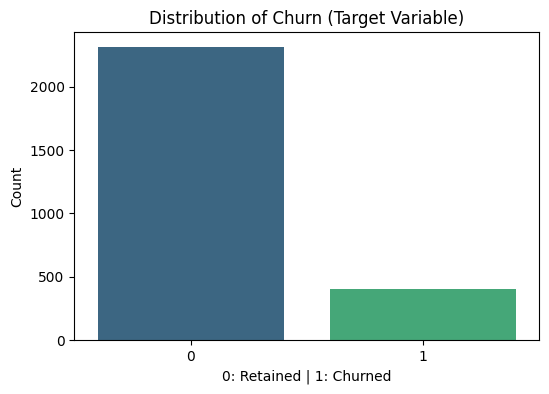

churn_label
0    85.130659
1    14.869341
Name: proportion, dtype: float64


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(6, 4))
sns.countplot(x='churn_label', data=df, palette='viridis')
plt.title('Distribution of Churn (Target Variable)')
plt.xlabel('0: Retained | 1: Churned')
plt.ylabel('Count')
plt.show()

print(df['churn_label'].value_counts(normalize=True) * 100)

Class imbalance observed. May need to use SMOTE to correct.

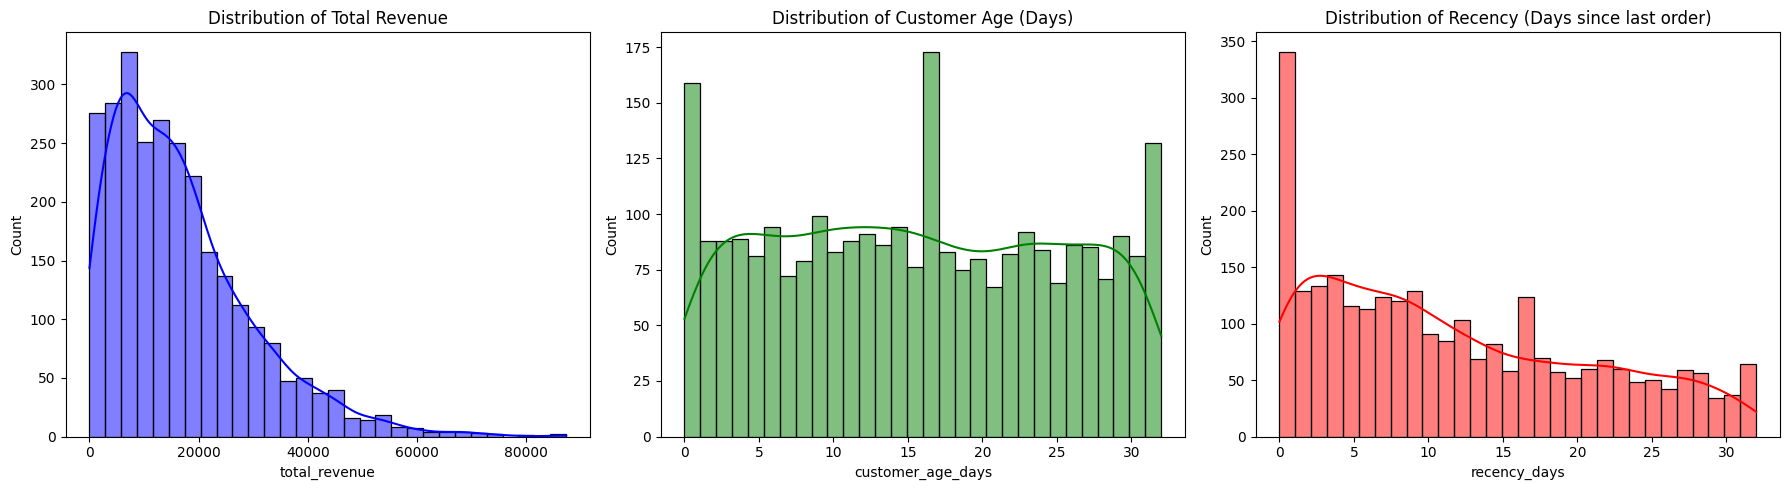

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['total_revenue'], bins=30, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Total Revenue')

sns.histplot(df['customer_age_days'], bins=30, kde=True, ax=axes[1], color='green')
axes[1].set_title('Distribution of Customer Age (Days)')

sns.histplot(df['recency_days'], bins=30, kde=True, ax=axes[2], color='red')
axes[2].set_title('Distribution of Recency (Days since last order)')

plt.tight_layout()
plt.show()

Total revenue is strongly skewed to the right.

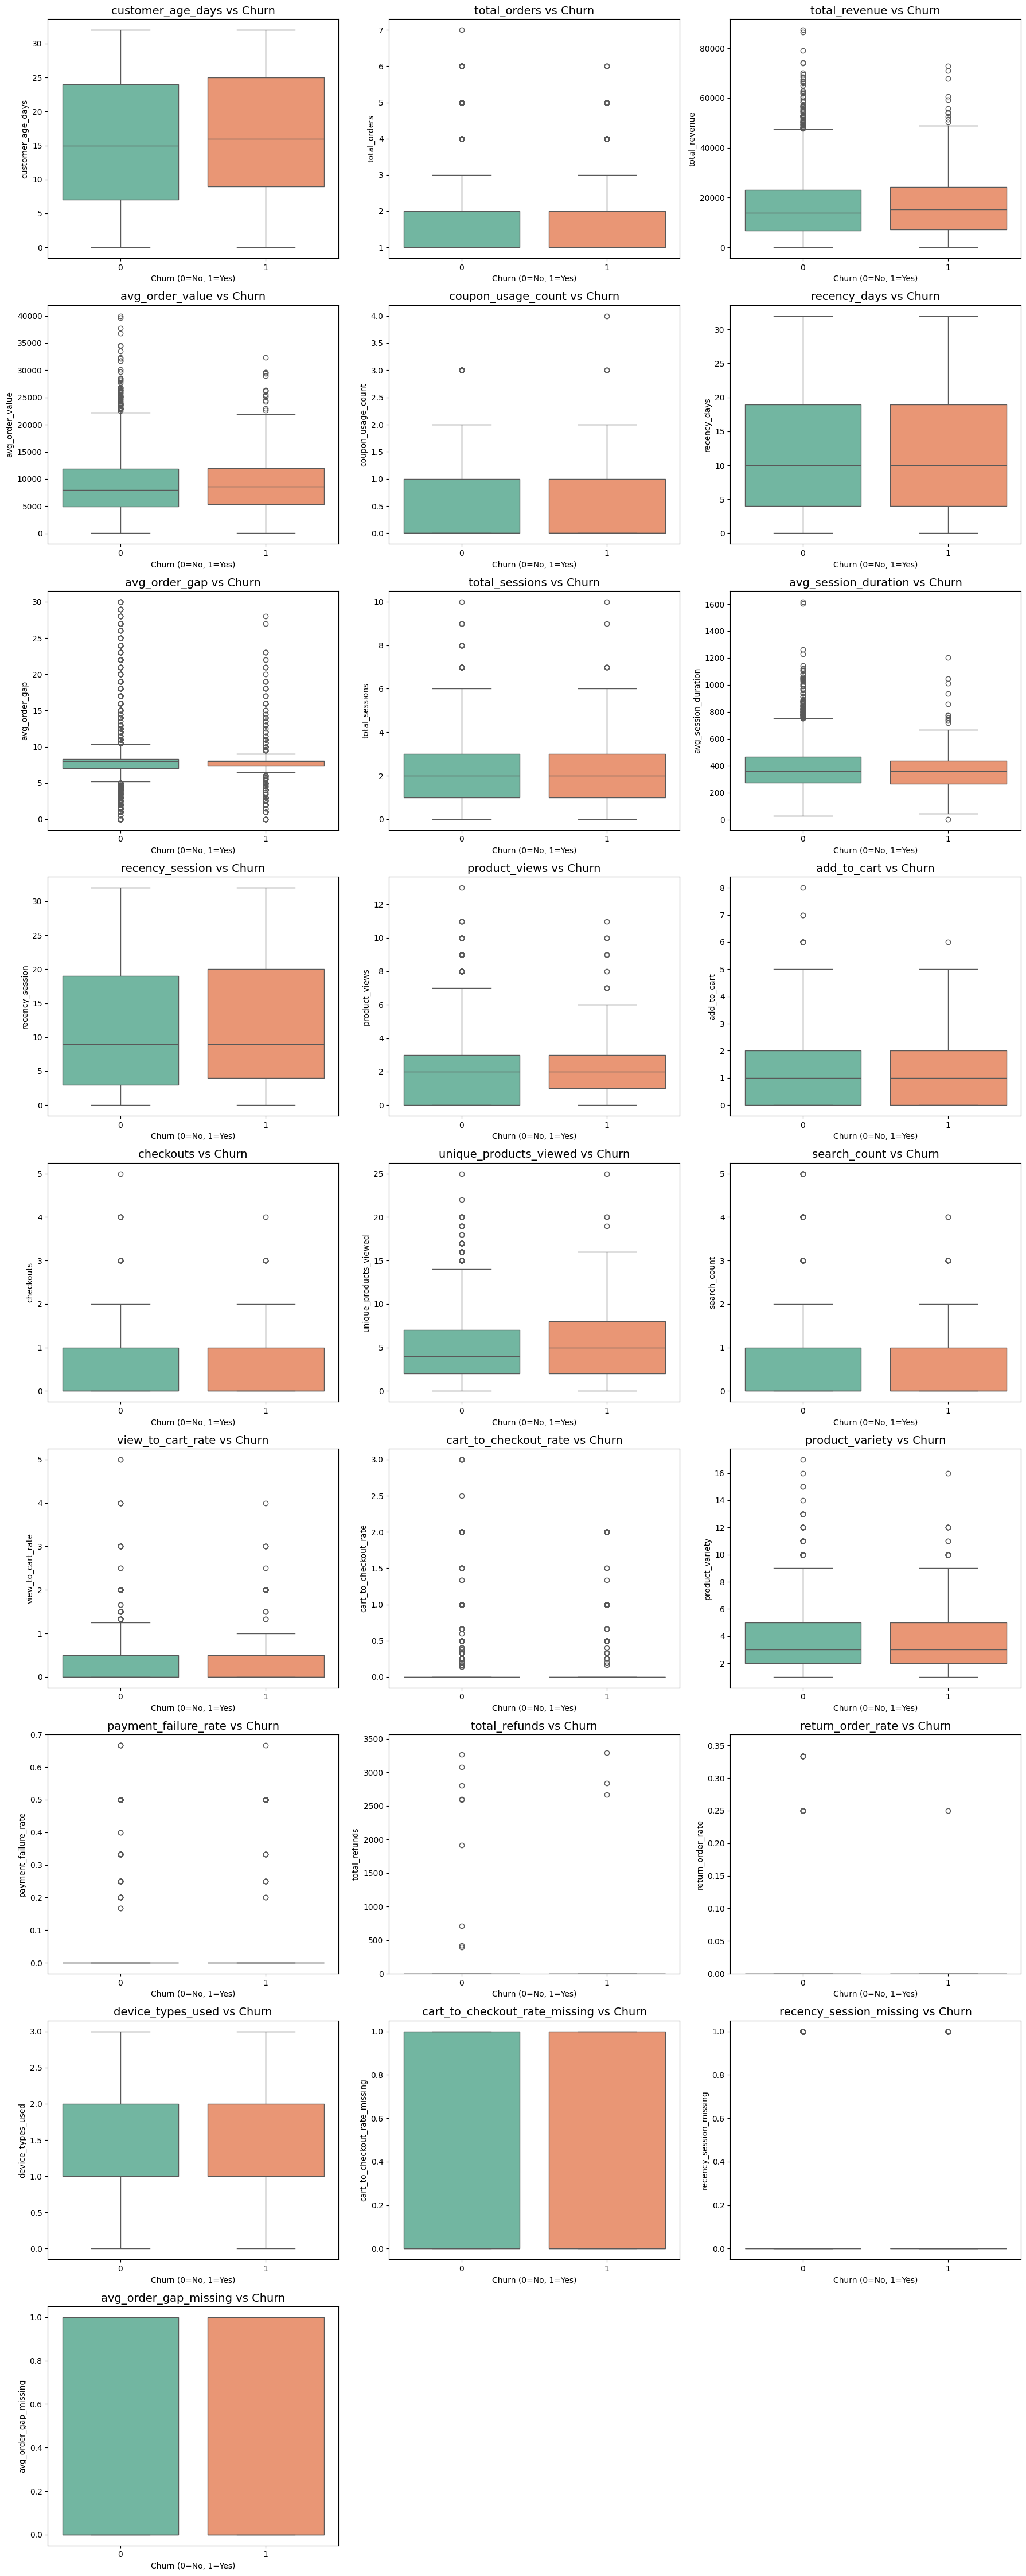

In [23]:

cols_to_exclude = ['customer_id', 'churn_label', 'view_to_cart_rate_missing']
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
cols_to_plot = [col for col in numeric_cols if col not in cols_to_exclude]

# 2. Define grid size (3 columns per row)
n_cols = 3
n_rows = math.ceil(len(cols_to_plot) / n_cols)

# 3. Create the plots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.boxplot(x='churn_label', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs Churn', fontsize=14)
    axes[i].set_xlabel('Churn (0=No, 1=Yes)')
    axes[i].set_ylabel(col)
    
    # Visualization adjustment: Cap the Y-axis at the 99th percentile if the max value is 
    # significantly higher (handles extreme outliers in revenue/sessions)
    q_high = df[col].quantile(0.99)
    if df[col].max() > q_high * 2: 
        axes[i].set_ylim(df[col].min(), q_high * 1.1)

# 4. Cleanup: Remove any empty subplots in the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

no numerical variables observed which behave significantly differently for churn and retention cases. 

In [25]:
df_1 = pd.get_dummies(df)
df_1

,customer_id,is_email_verified,marketing_opt_in,customer_age_days,total_orders,total_revenue,avg_order_value,coupon_usage_count,recency_days,avg_order_gap,...,cart_to_checkout_rate_missing,recency_session_missing,avg_order_gap_missing,acquisition_channel_affiliate,acquisition_channel_email,acquisition_channel_organic,acquisition_channel_paid,acquisition_channel_referral,country_India,country_United States
0,6,True,True,12.0,2,10944.97,5472.4850,1,21.0,5.0,...,0,0,0,False,False,False,True,False,True,False
1,10,True,True,6.0,2,7251.08,3625.5400,0,1.0,14.0,...,1,0,0,False,False,False,False,True,True,False
2,12,True,False,14.0,1,905.56,905.5600,0,5.0,8.0,...,1,0,1,False,False,True,False,False,False,True
3,14,False,False,19.0,4,25357.79,6339.4475,1,7.0,8.0,...,0,0,0,False,False,True,False,False,True,False
4,18,False,False,18.0,1,4071.43,4071.4300,1,0.0,8.0,...,0,0,1,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2712,9991,True,True,7.0,1,16693.24,16693.2400,1,1.0,8.0,...,0,0,1,False,False,True,False,False,True,False
2713,9994,True,False,30.0,2,6075.53,3037.7650,1,5.0,24.0,...,0,0,0,False,False,True,False,False,False,True
2714,9995,True,True,30.0,1,14986.95,14986.9500,1,31.0,8.0,...,1,0,1,False,False,True,False,False,True,False
2715,9996,True,False,31.0,3,35415.93,11805.3100,1,3.0,6.5,...,1,0,0,False,False,False,False,True,True,False


In [26]:
df_1.isnull().sum()

customer_id                      0
is_email_verified                0
marketing_opt_in                 0
customer_age_days                0
total_orders                     0
total_revenue                    0
avg_order_value                  0
coupon_usage_count               0
recency_days                     0
avg_order_gap                    0
total_sessions                   0
avg_session_duration             0
recency_session                  0
product_views                    0
add_to_cart                      0
checkouts                        0
unique_products_viewed           0
search_count                     0
view_to_cart_rate                0
cart_to_checkout_rate            0
product_variety                  0
payment_failure_rate             0
total_refunds                    0
return_order_rate                0
device_types_used                0
churn_label                      0
view_to_cart_rate_missing        0
cart_to_checkout_rate_missing    0
recency_session_miss

In [27]:
df_1['churn_label'].value_counts()

churn_label
0    2313
1     404
Name: count, dtype: int64

# Baseline Model

In [29]:

X = df_1.drop(['customer_id', 'churn_label'], axis=1)
y = df_1['churn_label']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

sm = SMOTE(sampling_strategy='auto', random_state=42)

X_train, y_train = sm.fit_resample(X_train, y_train)
ss = StandardScaler()
X_train_ss = ss.fit_transform(X_train)
X_test_ss = ss.transform(X_val)

In [30]:
scaler = StandardScaler()
from sklearn.pipeline import make_pipeline
model = LogisticRegression(class_weight = 'balanced')
pipeline = make_pipeline(scaler, model)

kfold = KFold(n_splits=10, shuffle=True, random_state=42)

scores = cross_val_score(pipeline, X, y, cv=kfold, scoring='f1_weighted')
print("F1 scores for each fold:", scores)
print("Mean F1:", np.mean(scores))

F1 scores for each fold: [0.62230801 0.6183364  0.60727875 0.56957751 0.60890814 0.59472343
 0.59512009 0.60755818 0.62920939 0.61687666]
Mean F1: 0.6069896553994056


In [31]:
y_train.value_counts()

churn_label
0    1618
1    1618
Name: count, dtype: int64

In [32]:
start = time.perf_counter()
model.fit(X_train_ss,y_train)
end = time.perf_counter()
logreg_time = end - start

<Axes: >

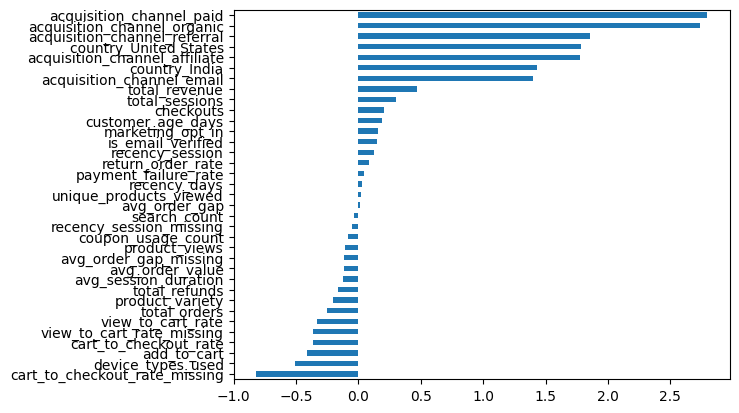

In [33]:
importance = pd.Series(model.coef_[0], index=X.columns)
importance.sort_values().plot(kind='barh')

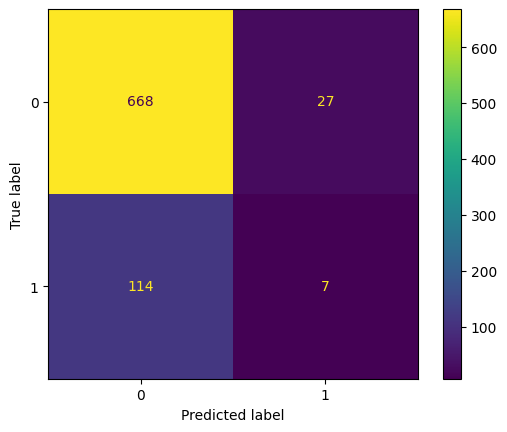

In [34]:
y_pred_ss = model.predict(X_test_ss)
cm = confusion_matrix(y_val,y_pred_ss)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=model.classes_)
disp.plot()
plt.show()

In [35]:
logreg_f1 = round(f1_score(y_pred_ss,y_val, average='macro'),2)
logreg_auc = round(roc_auc_score(y_pred_ss,y_val),2)
print("f1 score: ", logreg_f1)
print("AUC: ", logreg_auc)

f1 score:  0.5
AUC:  0.53


In [36]:
print(classification_report(y_pred_ss,y_val))

              precision    recall  f1-score   support

           0       0.96      0.85      0.90       782
           1       0.06      0.21      0.09        34

    accuracy                           0.83       816
   macro avg       0.51      0.53      0.50       816
weighted avg       0.92      0.83      0.87       816



# Explainable Boosting Machine

#import sys
#!{sys.executable} -m pip install interpret

#import sys
#!{sys.executable} -m pip install --upgrade scikit-learn


sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

ebm = ExplainableBoostingClassifier(n_jobs=1)



#ebm.fit(X_train, y_train, sample_weight=sample_weights)

kfold = KFold(n_splits=10, shuffle=True, random_state=42)

scores = cross_val_score(ebm, X, y, cv=kfold, scoring='f1_weighted')
print("F1 scores for each fold:", scores)
print("Mean F1:", np.mean(scores))

from interpret import show
start = time.perf_counter()
ebm.fit(X_train, y_train, sample_weight=sample_weights)
end = time.perf_counter()
ebm_time = end - start
ebm_global = ebm.explain_global()
show(ebm_global)

show(ebm.explain_local(X_val, y_val), 0)

y_pred = ebm.predict(X_val)
cm = confusion_matrix(y_pred,y_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=ebm.classes_)
disp.plot()
plt.show()

ebm_f1 = round(f1_score(y_pred,y_val,average='weighted'),2)
ebm_auc = round(roc_auc_score(y_pred,y_val),2)
print("f1 score: ", ebm_f1)
print("AUC: ", ebm_auc)

# Decision Tree Classifier

In [47]:
dtc = DecisionTreeClassifier(class_weight = 'balanced')
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(dtc, X, y, cv=kfold, scoring='f1_macro')
print("F1 scores for each fold:", scores)
print("Mean F1:", np.mean(scores))

F1 scores for each fold: [0.45797679 0.52586595 0.48898142 0.4984051  0.53793482 0.51406554
 0.54307655 0.56286738 0.48674242 0.4787168 ]
Mean F1: 0.509463277470522


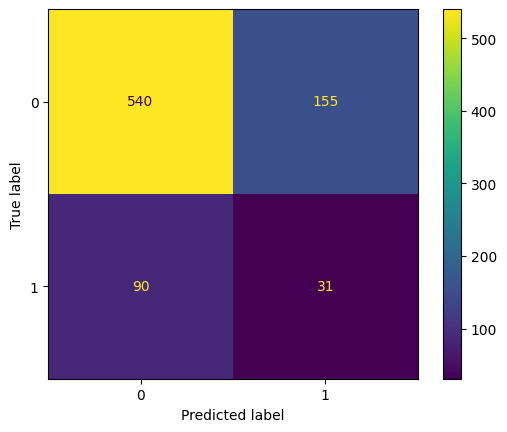

In [48]:
start = time.perf_counter()
dtc.fit(X_train, y_train)
end = time.perf_counter()
dtc_time = end - start
y_pred = dtc.predict(X_val)
cm = confusion_matrix(y_val,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=dtc.classes_)
disp.plot()
plt.show()

In [49]:
dtc_f1 = round(f1_score(y_pred,y_val,average='weighted'),2)
dtc_auc = round(roc_auc_score(y_pred,y_val),2)
print("f1 score: ", dtc_f1)
print("AUC: ", dtc_auc)

f1 score:  0.68
AUC:  0.51


# Naive Bayes

In [51]:
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline


nb = GaussianNB()
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(nb, X, y, cv=kfold, scoring='f1_weighted')
print("F1 scores for each fold:", scores)
print("Mean F1:", np.mean(scores))

F1 scores for each fold: [0.73159626 0.76138078 0.78572762 0.75973088 0.75842115 0.78632985
 0.78711772 0.79869897 0.77223387 0.77013848]
Mean F1: 0.7711375579302504


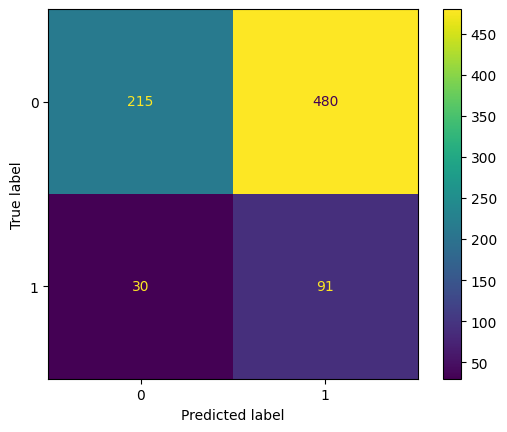

In [52]:
start = time.perf_counter()
nb.fit(X_train, y_train)
end = time.perf_counter()
nb_time = end - start
y_pred = nb.predict(X_val)
cm = confusion_matrix(y_val,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=nb.classes_)
disp.plot()
plt.show()

In [53]:
nb_f1 = round(f1_score(y_pred,y_val,average='weighted'),2)
nb_auc = round(roc_auc_score(y_pred,y_val),2)
print("f1 score: ", nb_f1)
print("AUC: ", nb_auc)

f1 score:  0.32
AUC:  0.52


# XGBoost

In [55]:
y_train.value_counts()

churn_label
0    1618
1    1618
Name: count, dtype: int64

In [56]:
scale_pos_weight= y_train.value_counts()[0]/y_train.value_counts()[1]
scale_pos_weight

1.0

In [57]:
model = XGBClassifier(scale_pos_weight=scale_pos_weight,eval_metric='logloss')

In [58]:
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

scores = cross_val_score(model, X, y, cv=kfold, scoring='f1_weighted')
print("F1 scores for each fold:", scores)
print("Mean F1:", np.mean(scores))

F1 scores for each fold: [0.75351563 0.75481744 0.78397477 0.76989586 0.77827949 0.79349012
 0.80417112 0.8134134  0.79042975 0.77480338]
Mean F1: 0.7816790977254959


## XGBoost Explanations

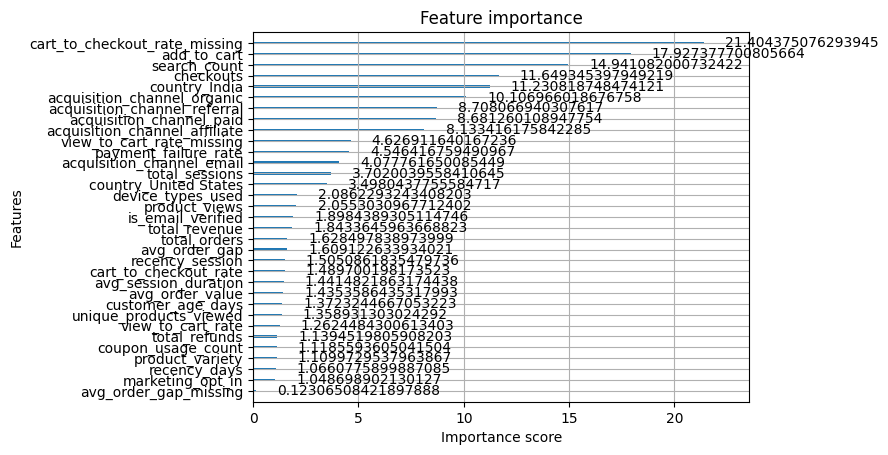

In [60]:
start = time.perf_counter()
model.fit(X_train, y_train)
end = time.perf_counter()
xgb_time = end - start

y_pred = model.predict(X_val)
plot_importance(model, importance_type="gain")
plt.show()

In [61]:
xgb_f1 = round(f1_score(y_pred,y_val,average='weighted'),2)
xgb_auc = round(roc_auc_score(y_pred,y_val),2)
print("f1 score: ", xgb_f1)
print("AUC: ", xgb_auc)

f1 score:  0.87
AUC:  0.52


In [62]:
#!{sys.executable} -m pip install lime


explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=["Not Churn", "Churn"],
    mode="classification"
)

exp = explainer.explain_instance(
    X_val.iloc[0].values,
    model.predict_proba
)

exp.show_in_notebook()

# Random Forest Classifier

In [64]:
rf = RandomForestClassifier(class_weight = 'balanced')
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(rf, X, y, cv=kfold, scoring='f1_weighted')
print("F1 scores for each fold:", scores)
print("Mean F1:", np.mean(scores))

F1 scores for each fold: [0.73869578 0.76965187 0.78524743 0.78524743 0.76965187 0.79568705
 0.79568705 0.81073095 0.78971191 0.78971191]
Mean F1: 0.7830023264045928


In [65]:
start = time.perf_counter()
rf.fit(X_train, y_train)
end = time.perf_counter()
rfc_time = end - start

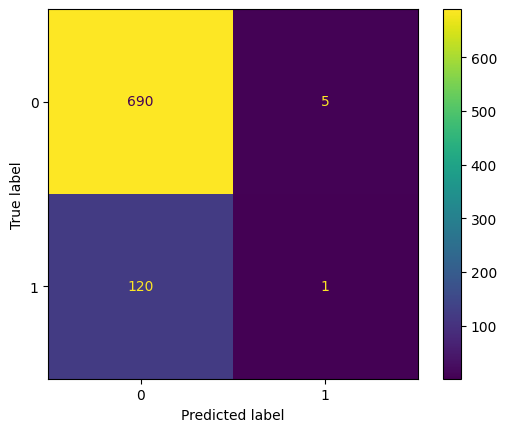

In [66]:
y_pred = rf.predict(X_val)
cm = confusion_matrix(y_val,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=rf.classes_)
disp.plot()
plt.show()

In [67]:
rfc_f1 = round(f1_score(y_val,y_pred,average='weighted'),2)
rfc_auc = round(roc_auc_score(y_val,y_pred),2)
print("f1 score: ", rfc_f1)
print("AUC: ", rfc_auc)

f1 score:  0.78
AUC:  0.5


In [68]:
import shap

In [69]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer(X_val)

In [70]:
shap_values[0][:,1]

.values =
array([ 5.64118682e-03, -5.43634398e-02,  1.56548541e-02,  8.41015156e-04,
        7.71742230e-03, -5.05954820e-04,  6.09870146e-03,  5.02192671e-03,
        1.60574162e-03, -4.60111528e-03,  8.35344311e-03, -2.41961372e-02,
       -7.38239845e-03, -3.46401976e-02, -8.84008903e-03,  8.24077228e-04,
       -3.13249349e-02,  1.28946150e-02, -3.28443870e-03,  6.40777653e-03,
       -2.67748338e-03, -5.05013883e-05, -1.57848121e-04, -3.74595966e-02,
        4.73044351e-03,  2.28354106e-02,  6.72298452e-04,  8.22402244e-04,
       -1.02731240e-02, -2.88294188e-03, -2.74503612e-02,  3.51225519e-02,
       -7.02893583e-03, -5.05211082e-02,  3.25327100e-02])

.base_values =
0.49986402966625465

.data =
array([0.00000000e+00, 0.00000000e+00, 3.20000000e+01, 1.00000000e+00,
       3.26032000e+03, 3.26032000e+03, 0.00000000e+00, 2.10000000e+01,
       8.00000000e+00, 3.00000000e+00, 3.25573508e+02, 1.00000000e+00,
       2.00000000e+00, 1.00000000e+00, 0.00000000e+00, 5.00000000e+00,
  

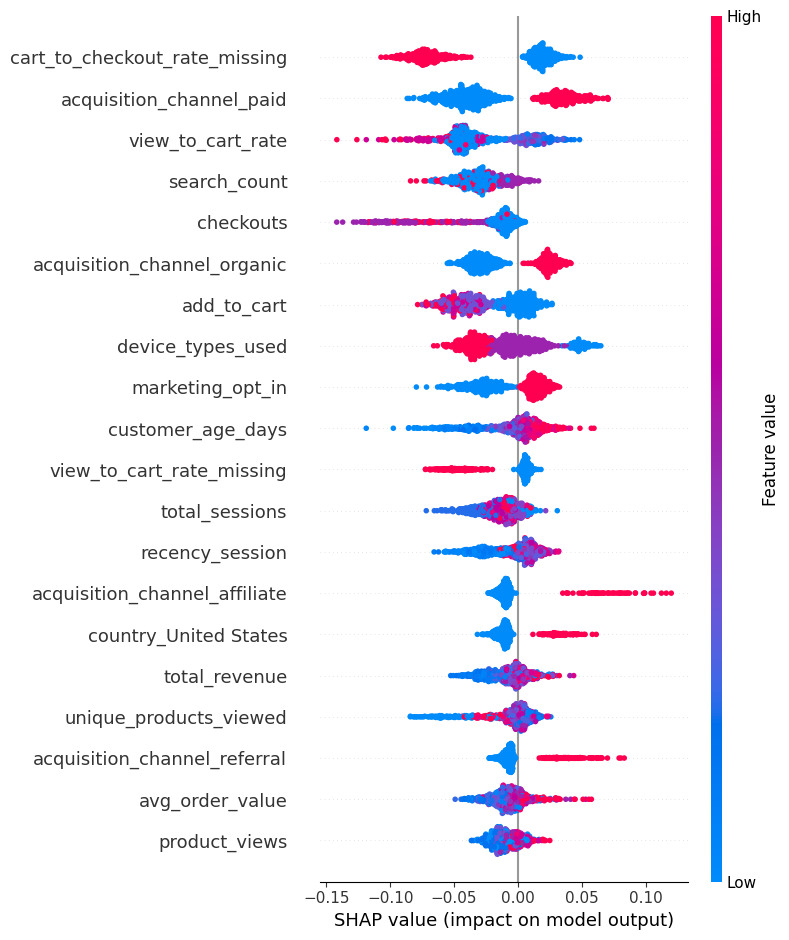

In [71]:
shap.summary_plot(shap_values[:, :, 1], X_val)

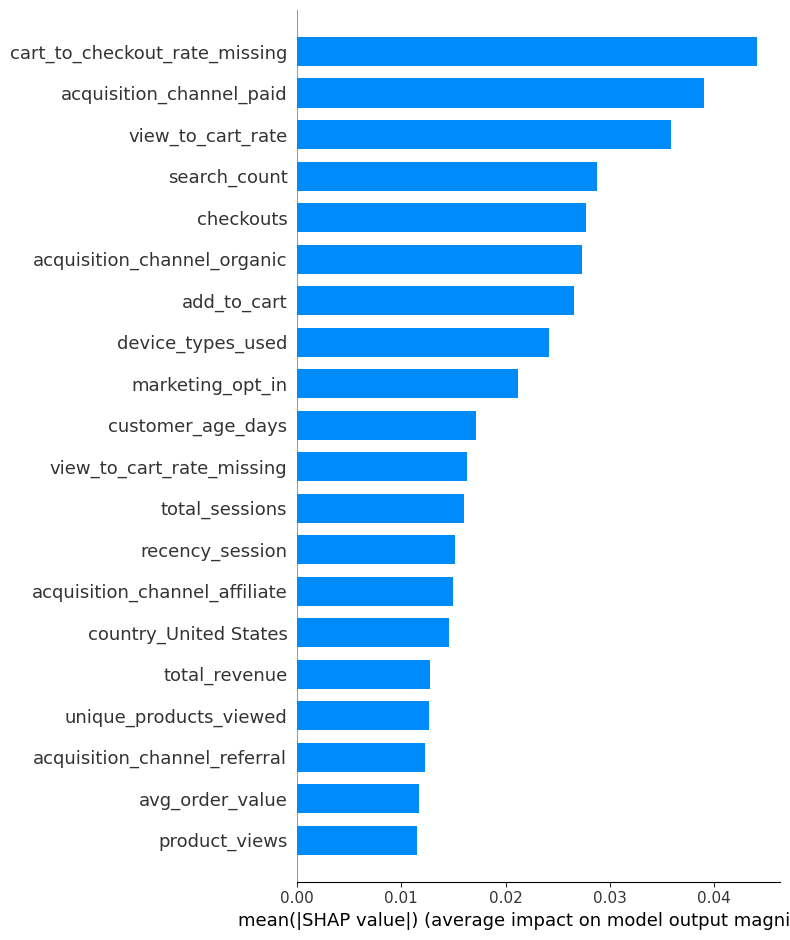

In [72]:
shap.summary_plot(shap_values[:, :, 1], X_val, plot_type="bar")

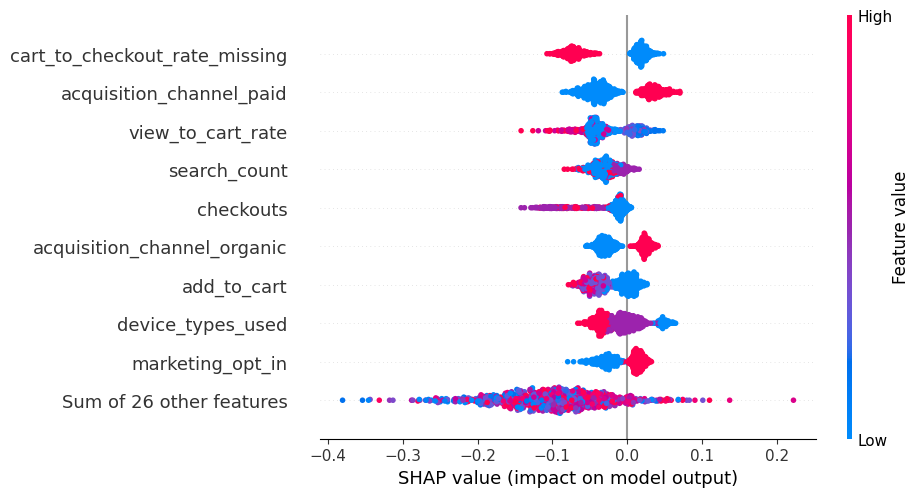

In [73]:
shap.plots.beeswarm(shap_values[:, :, 1])

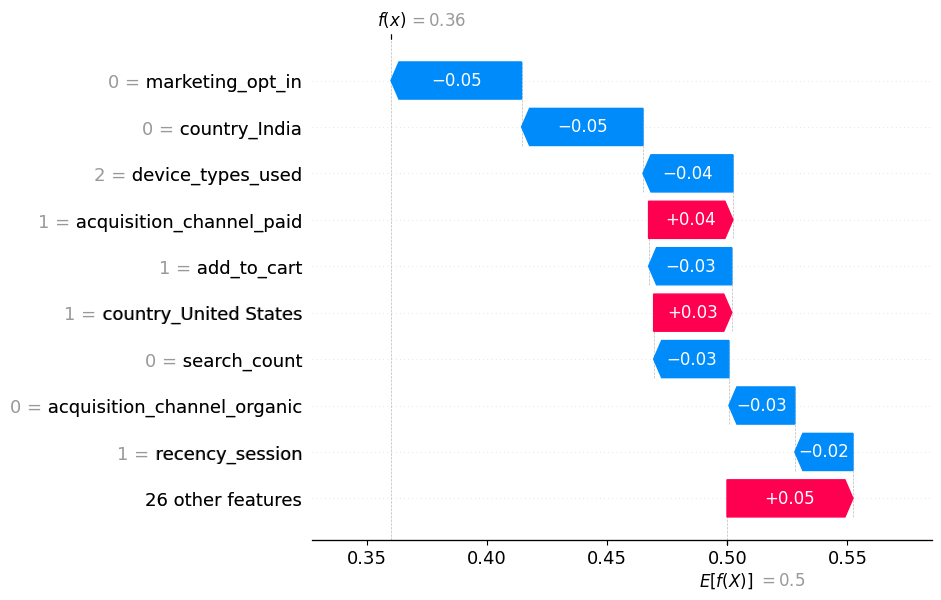

In [74]:
shap.plots.waterfall(shap_values[0][:,1])

# Voting Classifier

In [76]:

vt = VotingClassifier(
    estimators=[
        ('lr', Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(class_weight='balanced'))])),
        ('dtc', DecisionTreeClassifier(class_weight='balanced')),
        ('nb', GaussianNB()),
        ('rf', RandomForestClassifier(class_weight='balanced')),
        ('xgb', XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='logloss'))
    ],
   voting='soft'
)

scores = cross_val_score(vt, X, y, cv=10, scoring='f1_weighted')
print("F1 scores for each fold:", scores)
print("Mean F1:", np.mean(scores))

F1 scores for each fold: [0.79807487 0.78797861 0.77996521 0.78677495 0.79074739 0.78648798
 0.77821069 0.80529257 0.78877651 0.76957438]
Mean F1: 0.7871883147439098


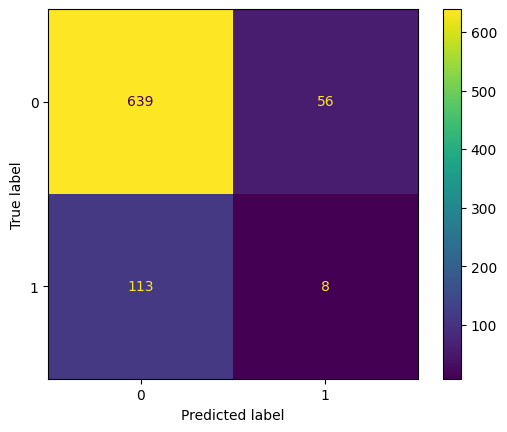

In [77]:
start = time.perf_counter()
vt.fit(X_train, y_train)
end = time.perf_counter()
voting_time = end - start

y_pred = vt.predict(X_val)
cm = confusion_matrix(y_val,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=vt.classes_)
disp.plot()
plt.show()

In [78]:
voting_f1 = round(f1_score(y_pred,y_val,average='weighted'),2)
voting_auc = round(roc_auc_score(y_pred,y_val),2)
print("f1 score: ", voting_f1)
print("AUC: ", voting_auc)

f1 score:  0.82
AUC:  0.49


# Stacking Classifier

In [80]:

stk = StackingClassifier(
    estimators=[
        ('lr', Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(class_weight='balanced'))])),
        ('dtc', DecisionTreeClassifier(class_weight='balanced')),
        ('nb', GaussianNB()),
        ('rf', RandomForestClassifier(class_weight='balanced')),
        ('xgb', XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='logloss'))],final_estimator=RandomForestClassifier(class_weight='balanced'), passthrough=False)


scores = cross_val_score(stk, X, y, cv=10, scoring='f1_weighted')
print("F1 scores for each fold:", scores)
print("Mean F1:", np.mean(scores))

F1 scores for each fold: [0.78157956 0.78341714 0.80238151 0.78004035 0.78004035 0.77821069
 0.78677495 0.78447832 0.79324422 0.78721865]
Mean F1: 0.7857385735547281


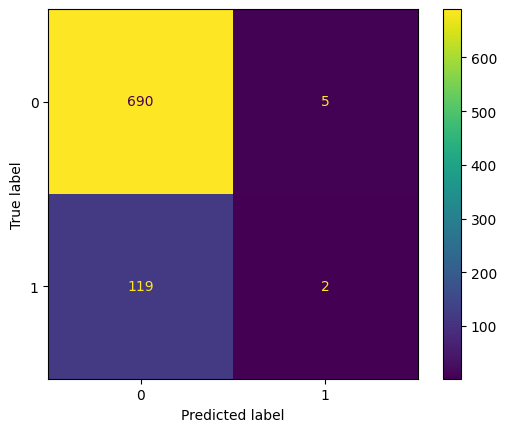

In [81]:
start = time.perf_counter()
stk.fit(X_train, y_train)
end = time.perf_counter()
stacking_time = end - start
y_pred = stk.predict(X_val)
cm = confusion_matrix(y_val,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=stk.classes_)
disp.plot()
plt.show()

In [82]:
tn, fp, fn, tp = cm.ravel()
tp,tn

(2, 690)

In [83]:
stacking_f1 = round(f1_score(y_pred,y_val,average='micro'),2)
stacking_auc = round(roc_auc_score(y_pred,y_val),2)
print("f1 score: ", stacking_f1)
print("AUC: ", stacking_auc)

f1 score:  0.85
AUC:  0.57


In [84]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.99      0.92       695
           1       0.29      0.02      0.03       121

    accuracy                           0.85       816
   macro avg       0.57      0.50      0.47       816
weighted avg       0.77      0.85      0.79       816



In [85]:
import pandas as pd

models = {'logreg':"Logistic Regression", 'dtc': "Decision Tree", 'nb': "Naive Bayes" ,'xgb':"XGBoost", 'rfc':"Random Forest", 'voting': 'Voting Classifier','stacking':"Stacking Classifier"}

summary = pd.DataFrame({
    'Model': list(models.values()),
    'F1 Score': [f"{eval(f"{m}_f1")*100}%" for m in models.keys()],
    'AUC': [f"{eval(f"{m}_auc")*100}%" for m in models.keys()],
    'Training Time': [eval(f"{m}_time") for m in models.keys()]
})

summary

,Model,F1 Score,AUC,Training Time
0,Logistic Regression,50.0%,53.0%,0.062477
1,Decision Tree,68.0%,51.0%,0.084466
2,Naive Bayes,32.0%,52.0%,0.018110
3,XGBoost,87.0%,52.0%,0.703335
4,Random Forest,78.0%,50.0%,1.305361
5,Voting Classifier,82.0%,49.0%,2.273181
6,Stacking Classifier,85.0%,56.99999999999999%,13.178299


The stacking classifier shows over 35% increase in F1 Score andt takes 7 seconds to train as compared to 0.03 for logistic regression. 

And yet, none of the models significantly outperform random on this scale as maximum AUC is 53%.

This usecase would benefit from 12+ months of history and a longer churn window (60-90d). 

#### Recommendation:
do not deploy as-is; Collect more data and iterate for performance.

PermutationExplainer explainer: 101it [03:46,  2.27s/it]                                                               


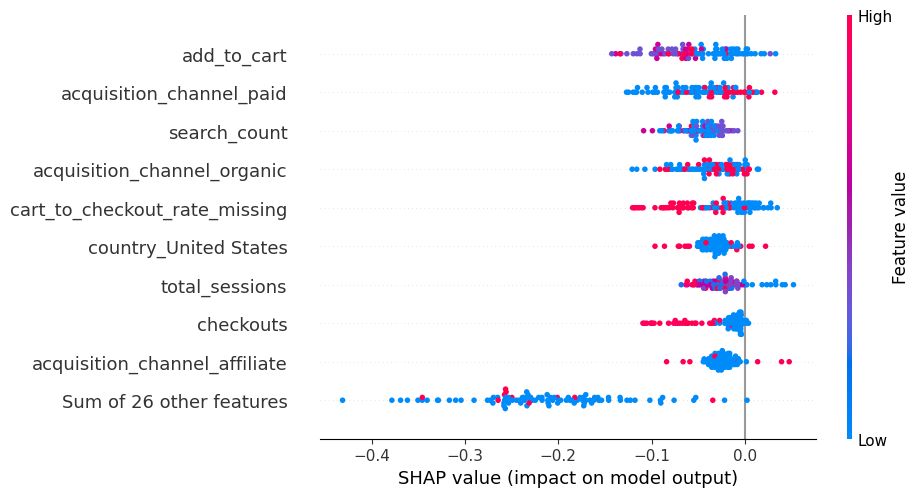

In [87]:
# Convert everything to float to avoid the NumPy 'isfinite' error
X_train_numeric = X_train.astype(float)
X_val_numeric = X_val.astype(float)

# Use the numeric background data as the masker
explainer = shap.Explainer(stk.predict_proba, X_train_numeric)
shap_values = explainer(X_val_numeric.iloc[:100])

# Visualize the positive class (Churn)
shap.plots.beeswarm(shap_values[:, :, 1])

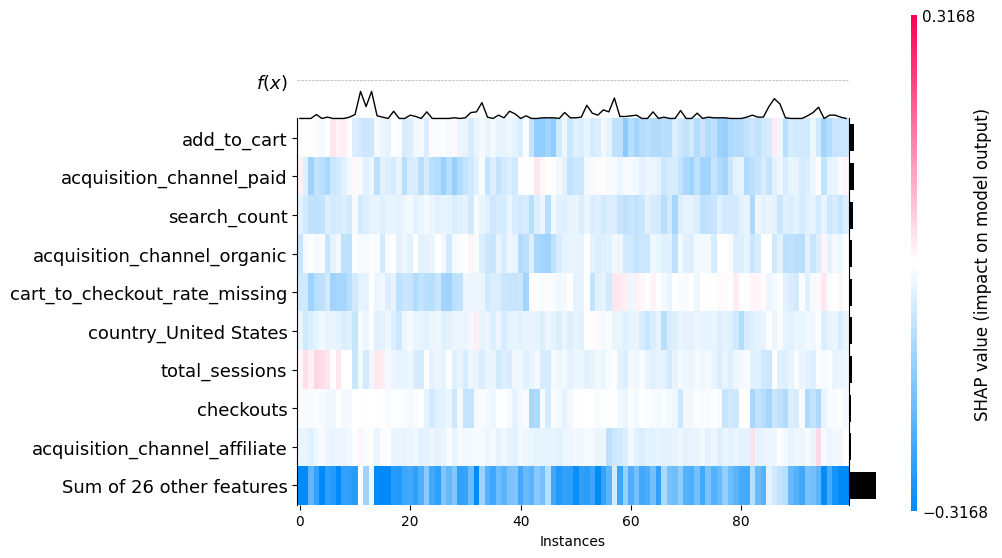

<Axes: xlabel='Instances'>

In [88]:
shap.plots.heatmap(shap_values[:, :, 1])

Explaining the model using only the first 100 datapoints of test set takes 2 minutes